# Pipeline para explicar minimización

In [24]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.linear_model import LinearRegression # Modelo de regresión lineal
from sklearn.model_selection import train_test_split, cross_val_score # Funciones para dividir el dataset y evaluar el modelo
from sklearn.pipeline import Pipeline # Para crear un pipeline de procesamiento y modelado
from sklearn.preprocessing import PolynomialFeatures # Para crear características polinómicas

In [44]:
X = np.linspace(0, 10, 100)
e = np.random.random(100) # Ruido (Gaussiano)
y = np.sin(X) + e * 2 # Variable dependiente con ruido

<Axes: >

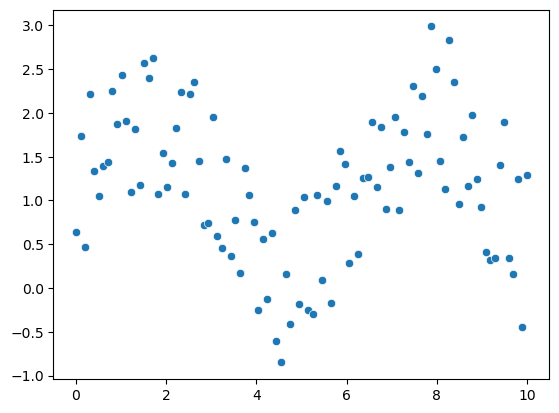

In [45]:
sns.scatterplot(x=X, y=y)

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((80,), (20,), (80,), (20,))

In [49]:
X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)

pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=6) # Para crear características polinómicas
    ),
    ("lr", LinearRegression())
])
score = cross_val_score(pipeline, X_train, y_train, cv=5,
                         scoring="neg_mean_squared_error")
score = - score # Para convertirlo a positivo
score.mean()

np.float64(0.3829551753014211)

<Axes: >

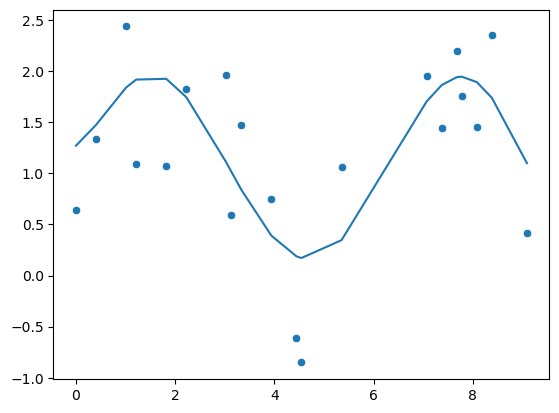

In [50]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test) # Predicciones del modelo
sns.scatterplot(x=X_test.reshape(-1), y=y_test) # Gráfico de los datos reales
sns.lineplot(x=X_test.reshape(-1), y=y_pred) # Gráfico de las predicciones del modelo